<a href="https://colab.research.google.com/github/bandiamithsreenivasareddy/CATPIC-Context-Aware-Framework-for-Political-Content-Moderation-NLP/blob/main/NLP_2_multi_tast_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook 2: Multi-Task BERT Model — Detection + Span + Target + Severity

CATPIC — Context-Aware Framework for Political Toxicity Analysis

This notebook trains a multi-task BERT model with 4 heads:

1. Toxicity Classification (3-class: hate, offensive, normal)
2. Toxic Span Detection (token-level binary)
3. Target Community Identification (multi-label)
4. Severity Regression (0-1 score)

Run Notebook 1 first to generate processed data.

In [ ]:
# ============================================================
# Cell 1: Install & Imports
# ============================================================
!pip install -q transformers accelerate scikit-learn tqdm

import os
import pickle
import json
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
# ============================================================
# Cell 1b: Google Drive Setup — mount to persist model checkpoints
# ============================================================
import shutil

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = '/content/drive/MyDrive/CATPIC_Project/'
    os.makedirs(DRIVE_BASE + 'models/', exist_ok=True)
    USE_DRIVE = True
    print(f'Google Drive mounted. Checkpoints will be saved to:\n {DRIVE_BASE}models/')

    # If processed data exists on Drive but not locally, copy it down
    drive_pkl = DRIVE_BASE + 'data/processed/hatexplain_processed.pkl'
    local_pkl = 'data/processed/hatexplain_processed.pkl'
    if not os.path.exists(local_pkl) and os.path.exists(drive_pkl):
        os.makedirs('data/processed/', exist_ok=True)
        shutil.copy(drive_pkl, local_pkl)
        print('Restored hatexplain_processed.pkl from Drive.')
except ImportError:
    USE_DRIVE = False
    print('Not running on Colab — Google Drive mounting skipped.')

Mounted at /content/drive
Google Drive mounted. Checkpoints will be saved to:
 /content/drive/MyDrive/CATPIC_Project/models/
Restored hatexplain_processed.pkl from Drive.


In [ ]:
# ============================================================
# Cell 2: Load processed data
# ============================================================
with open('data/processed/hatexplain_processed.pkl', 'rb') as f:
    hatex_data = pickle.load(f)

train_df = hatex_data['train']
val_df = hatex_data['val']
test_df = hatex_data['test']
target2id = hatex_data['target2id']
id2target = hatex_data['id2target']
num_targets = hatex_data['num_targets']
label_map = hatex_data['label_map']
id2label = {v: k for k, v in label_map.items()}

NUM_LABELS = 3  # hatespeech, offensive, normal
NUM_TARGETS = num_targets
MAX_LEN = 128

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
print(f'Num labels: {NUM_LABELS}, Num targets: {NUM_TARGETS}')
print(f'Target communities: {list(target2id.keys())}')

Train: 15383, Val: 1922, Test: 1924
Num labels: 3, Num targets: 25
Target communities: ['African', 'Arab', 'Asexual', 'Asian', 'Bisexual', 'Buddhism', 'Caucasian', 'Christian', 'Disability', 'Economic', 'Heterosexual', 'Hindu', 'Hispanic', 'Homosexual', 'Indian', 'Indigenous', 'Islam', 'Jewish', 'Men', 'Minority', 'None', 'Nonreligious', 'Other', 'Refugee', 'Women']


In [ ]:
# ============================================================
# Cell 3: Tokenizer and Dataset class
# ============================================================
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

class HateXplainDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tokens = row['tokens']
        text = row['text']
        label_id = row['label_id']
        rationale = row['rationale']
        target_encoded = row['target_encoded']
        severity = row['severity']

        # Tokenize with word-level alignment
        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
            return_offsets_mapping=False
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # Align rationale labels with BERT wordpiece tokens
        word_ids = encoding.word_ids(batch_index=0)
        aligned_rationale = []
        for wid in word_ids:
            if wid is None:
                aligned_rationale.append(-100)  # ignore [CLS], [SEP], [PAD]
            elif wid < len(rationale):
                aligned_rationale.append(rationale[wid])
            else:
                aligned_rationale.append(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'label': torch.tensor(label_id, dtype=torch.long),
            'span_labels': torch.tensor(aligned_rationale, dtype=torch.long),
            'target_labels': torch.tensor(target_encoded, dtype=torch.float),
            'severity': torch.tensor(severity, dtype=torch.float),
        }


# Create datasets
train_dataset = HateXplainDataset(train_df, tokenizer, MAX_LEN)
val_dataset = HateXplainDataset(val_df, tokenizer, MAX_LEN)
test_dataset = HateXplainDataset(test_df, tokenizer, MAX_LEN)

# Test one sample
sample = train_dataset[0]
print('Sample shapes:')
for k, v in sample.items():
    print(f'  {k}: {v.shape}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sample shapes:
  input_ids: torch.Size([128])
  attention_mask: torch.Size([128])
  label: torch.Size([])
  span_labels: torch.Size([128])
  target_labels: torch.Size([25])
  severity: torch.Size([])


In [ ]:
# ============================================================
# Cell 4: Multi-Task BERT Model
# ============================================================
class CATPICMultiTaskBERT(nn.Module):
    """Context-Aware Toxicity Pipeline with Intelligent Classification.

    Multi-task model with shared BERT encoder and 4 task-specific heads:
    1. Toxicity classification (CLS token → 3-class)
    2. Toxic span detection (token-level → binary per token)
    3. Target community identification (CLS token → multi-label)
    4. Severity regression (CLS token → scalar 0-1)
    """

    def __init__(self, num_labels=3, num_targets=10, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        hidden_size = self.bert.config.hidden_size  # 768

        # Head 1: Toxicity Classification (3-class)
        self.classification_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels)
        )

        # Head 2: Toxic Span Detection (token-level binary)
        self.span_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 2)  # binary: toxic / not-toxic per token
        )

        # Head 3: Target Community (multi-label)
        self.target_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_targets)
        )

        # Head 4: Severity Regression (scalar 0-1)
        self.severity_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls_output = outputs.last_hidden_state[:, 0, :]  # [batch, 768]
        seq_output = outputs.last_hidden_state           # [batch, seq_len, 768]

        # Head outputs
        class_logits = self.classification_head(cls_output)   # [batch, 3]
        span_logits = self.span_head(seq_output)              # [batch, seq_len, 2]
        target_logits = self.target_head(cls_output)          # [batch, num_targets]
        severity_pred = self.severity_head(cls_output).view(-1)  # [batch]

        return class_logits, span_logits, target_logits, severity_pred


# Instantiate model
model = CATPICMultiTaskBERT(num_labels=NUM_LABELS, num_targets=NUM_TARGETS, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 110,080,415
Trainable parameters: 110,080,415


In [ ]:
# ============================================================
# Cell 5: Loss functions and training setup
# ============================================================
# Class weights for imbalanced labels
label_counts = train_df['label_id'].value_counts().sort_index()
total = len(train_df)
class_weights = torch.tensor([total / (NUM_LABELS * c) for c in label_counts.values], dtype=torch.float).to(device)
print(f'Class weights: {class_weights}')

# Loss functions
classification_loss_fn = nn.CrossEntropyLoss(weight=class_weights)
span_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
target_loss_fn = nn.BCEWithLogitsLoss()
severity_loss_fn = nn.MSELoss()

# Loss weights (tunable)
LOSS_WEIGHTS = {
    'classification': 1.0,
    'span': 1.0,
    'target': 0.5,
    'severity': 0.5
}

# DataLoaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Optimizer and Scheduler
LEARNING_RATE = 2e-5
NUM_EPOCHS = 5
WARMUP_STEPS = len(train_loader) // 3

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps)

print(f'Batch size: {BATCH_SIZE}')
print(f'Total training steps: {total_steps}')
print(f'Warmup steps: {WARMUP_STEPS}')

Class weights: tensor([1.0800, 1.1696, 0.8203], device='cuda:0')
Batch size: 16
Total training steps: 4810
Warmup steps: 320


In [ ]:
# ============================================================
# Cell 6: Training and Evaluation functions
# ============================================================
def compute_multi_task_loss(class_logits, span_logits, target_logits, severity_pred, batch):
    """Compute weighted multi-task loss."""
    loss_cls = classification_loss_fn(class_logits, batch['label'].to(device))

    # Span loss: reshape for cross-entropy
    span_logits_flat = span_logits.view(-1, 2)
    span_labels_flat = batch['span_labels'].to(device).view(-1)
    loss_span = span_loss_fn(span_logits_flat, span_labels_flat)

    loss_target = target_loss_fn(target_logits, batch['target_labels'].to(device))
    loss_severity = severity_loss_fn(severity_pred, batch['severity'].to(device))

    total_loss = (
        LOSS_WEIGHTS['classification'] * loss_cls +
        LOSS_WEIGHTS['span'] * loss_span +
        LOSS_WEIGHTS['target'] * loss_target +
        LOSS_WEIGHTS['severity'] * loss_severity
    )

    return total_loss, {
        'cls': loss_cls.item(),
        'span': loss_span.item(),
        'target': loss_target.item(),
        'severity': loss_severity.item(),
        'total': total_loss.item()
    }


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_losses = {'cls': 0, 'span': 0, 'target': 0, 'severity': 0, 'total': 0}
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='Training', leave=False):
        optimizer.zero_grad()

        class_logits, span_logits, target_logits, severity_pred = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )

        loss, loss_dict = compute_multi_task_loss(
            class_logits, span_logits, target_logits, severity_pred, batch
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        for k in total_losses:
            total_losses[k] += loss_dict[k]

        preds = torch.argmax(class_logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch['label'].numpy())

    n = len(loader)
    avg_losses = {k: v / n for k, v in total_losses.items()}
    train_f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_losses, train_f1


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_losses = {'cls': 0, 'span': 0, 'target': 0, 'severity': 0, 'total': 0}
    all_preds, all_labels = [], []
    all_span_preds, all_span_labels = [], []
    all_severity_preds, all_severity_labels = [], []
    all_target_preds, all_target_labels = [], []

    for batch in tqdm(loader, desc='Evaluating', leave=False):
        class_logits, span_logits, target_logits, severity_pred = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )

        loss, loss_dict = compute_multi_task_loss(
            class_logits, span_logits, target_logits, severity_pred, batch
        )

        for k in total_losses:
            total_losses[k] += loss_dict[k]

        # Classification predictions
        preds = torch.argmax(class_logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch['label'].numpy())

        # Span predictions (only for non-padding, non-special tokens)
        span_pred = torch.argmax(span_logits, dim=-1).cpu()  # [batch, seq_len]
        span_lab = batch['span_labels']  # [batch, seq_len]
        mask = span_lab != -100
        all_span_preds.extend(span_pred[mask].numpy().tolist())
        all_span_labels.extend(span_lab[mask].numpy().tolist())

        # Severity
        all_severity_preds.extend(severity_pred.cpu().numpy().tolist())
        all_severity_labels.extend(batch['severity'].numpy().tolist())

        # Target predictions
        target_pred = (torch.sigmoid(target_logits) > 0.5).cpu().numpy()
        all_target_preds.extend(target_pred.tolist())
        all_target_labels.extend(batch['target_labels'].numpy().tolist())

    n = len(loader)
    avg_losses = {k: v / n for k, v in total_losses.items()}

    # Classification metrics
    cls_f1 = f1_score(all_labels, all_preds, average='macro')

    # Span detection metrics
    span_f1 = f1_score(all_span_labels, all_span_preds, average='binary', zero_division=0)

    # Target metrics
    target_preds_flat = np.array(all_target_preds).flatten()
    target_labels_flat = np.array(all_target_labels).flatten()
    target_f1 = f1_score(target_labels_flat, target_preds_flat, average='macro', zero_division=0)

    # Severity MAE
    severity_mae = np.mean(np.abs(np.array(all_severity_preds) - np.array(all_severity_labels)))

    metrics = {
        'cls_f1': cls_f1,
        'span_f1': span_f1,
        'target_f1': target_f1,
        'severity_mae': severity_mae,
        'all_preds': all_preds,
        'all_labels': all_labels
    }

    return avg_losses, metrics

print('Training functions ready.')

Training functions ready.


In [ ]:
os.makedirs('models', exist_ok=True)

In [ ]:
# ============================================================
# Cell 7: Training Loop
# ============================================================
history = {
    'train_loss': [], 'val_loss': [],
    'train_f1': [], 'val_cls_f1': [],
    'val_span_f1': [], 'val_target_f1': [], 'val_severity_mae': []
}

best_val_f1 = 0
patience = 2
patience_counter = 0

print('='*70)
print('Starting Multi-Task BERT Training')
print('='*70)

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-'*50)

    # Train
    train_losses, train_f1 = train_epoch(model, train_loader, optimizer, scheduler)

    # Validate
    val_losses, val_metrics = evaluate(model, val_loader)

    # Log
    history['train_loss'].append(train_losses['total'])
    history['val_loss'].append(val_losses['total'])
    history['train_f1'].append(train_f1)
    history['val_cls_f1'].append(val_metrics['cls_f1'])
    history['val_span_f1'].append(val_metrics['span_f1'])
    history['val_target_f1'].append(val_metrics['target_f1'])
    history['val_severity_mae'].append(val_metrics['severity_mae'])

    print(f'  Train Loss: {train_losses["total"]:.4f} | Train F1: {train_f1:.4f}')
    print(f'  Val Loss:   {val_losses["total"]:.4f}')
    print(f'  Val Classification F1: {val_metrics["cls_f1"]:.4f}')
    print(f'  Val Span Detection F1: {val_metrics["span_f1"]:.4f}')
    print(f'  Val Target ID F1:      {val_metrics["target_f1"]:.4f}')
    print(f'  Val Severity MAE:      {val_metrics["severity_mae"]:.4f}')

    # Save best model
    combined_score = (val_metrics['cls_f1'] + val_metrics['span_f1']) / 2
    if combined_score > best_val_f1:
        best_val_f1 = combined_score
        torch.save({
            'model_state_dict': model.state_dict(),
            'epoch': epoch,
            'best_val_f1': best_val_f1,
            'num_labels': NUM_LABELS,
            'num_targets': NUM_TARGETS,
            'target2id': target2id,
            'id2target': id2target,
            'label_map': label_map,
        }, 'models/catpic_multitask_bert_best.pt')
        print(f'  >>> New best model saved! (combined F1: {combined_score:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

print('\n' + '='*70)
print('Training complete!')
print('='*70)

Starting Multi-Task BERT Training

Epoch 1/5
--------------------------------------------------


Training:   0%|          | 0/962 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/121 [00:00<?, ?it/s]

  Train Loss: 1.1708 | Train F1: 0.7168
  Val Loss:   1.2557
  Val Classification F1: 0.6842
  Val Span Detection F1: 0.5571
  Val Target ID F1:      0.6690
  Val Severity MAE:      0.2365
  >>> New best model saved! (combined F1: 0.6206)

Epoch 2/5
--------------------------------------------------


Training:   0%|          | 0/962 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/121 [00:00<?, ?it/s]

  Train Loss: 0.6529 | Train F1: 0.8988
  Val Loss:   1.5879
  Val Classification F1: 0.6678
  Val Span Detection F1: 0.5698
  Val Target ID F1:      0.6700
  Val Severity MAE:      0.2319

Epoch 5/5
--------------------------------------------------


Training:   0%|          | 0/962 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/121 [00:00<?, ?it/s]

  Train Loss: 0.6067 | Train F1: 0.9136
  Val Loss:   1.5879
  Val Classification F1: 0.6678
  Val Span Detection F1: 0.5698
  Val Target ID F1:      0.6700
  Val Severity MAE:      0.2319
  Early stopping at epoch 5

Training complete!


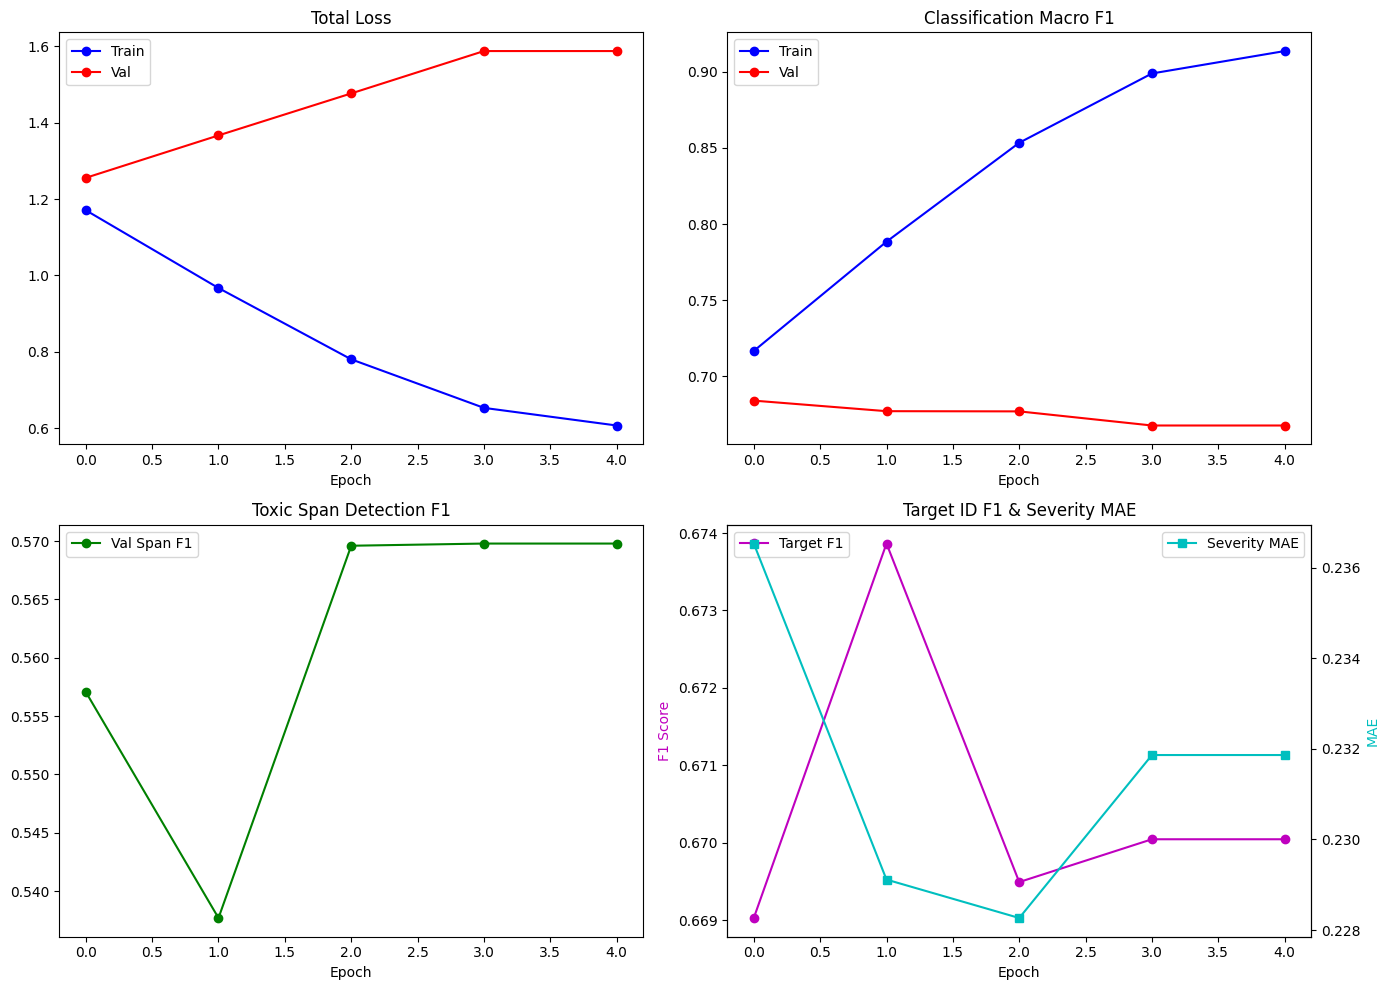

In [ ]:
# ============================================================
# Cell 8: Plot training curves
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
axes[0, 0].plot(history['train_loss'], 'b-o', label='Train')
axes[0, 0].plot(history['val_loss'], 'r-o', label='Val')
axes[0, 0].set_title('Total Loss')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Epoch')

# Classification F1
axes[0, 1].plot(history['train_f1'], 'b-o', label='Train')
axes[0, 1].plot(history['val_cls_f1'], 'r-o', label='Val')
axes[0, 1].set_title('Classification Macro F1')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Epoch')

# Span F1
axes[1, 0].plot(history['val_span_f1'], 'g-o', label='Val Span F1')
axes[1, 0].set_title('Toxic Span Detection F1')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Epoch')

# Target F1 + Severity MAE
ax_target = axes[1, 1]
ax_target.plot(history['val_target_f1'], 'm-o', label='Target F1')
ax_target.set_ylabel('F1 Score', color='m')

ax_sev = ax_target.twinx()
ax_sev.plot(history['val_severity_mae'], 'c-s', label='Severity MAE')
ax_sev.set_ylabel('MAE', color='c')

ax_target.set_title('Target ID F1 & Severity MAE')
ax_target.legend(loc='upper left')
ax_sev.legend(loc='upper right')
ax_target.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('models/training_curves_multitask.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Cell 9: Test Set Evaluation
# ============================================================

# Load best model
checkpoint = torch.load('models/catpic_multitask_bert_best.pt', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate on test set
test_losses, test_metrics = evaluate(model, test_loader)

print('\n' + '='*70)
print('TEST SET RESULTS')
print('='*70)

print(f"Classification Macro F1: {test_metrics['cls_f1']:.4f}")
print(f"Span Detection F1:     {test_metrics['span_f1']:.4f}")
print(f"Target ID F1:          {test_metrics['target_f1']:.4f}")
print(f"Severity MAE:          {test_metrics['severity_mae']:.4f}")

print('\n--- Classification Report ---')
print(classification_report(
    test_metrics['all_labels'],
    test_metrics['all_preds'],
    target_names=['hatespeech', 'offensive', 'normal'],
    digits=4
))

Loaded best model from epoch 3


Evaluating:   0%|          | 0/121 [00:00<?, ?it/s]


TEST SET RESULTS
Classification Macro F1: 0.6838
Span Detection F1:     0.5929
Target ID F1:          0.6783
Severity MAE:          0.2194

--- Classification Report ---
              precision    recall  f1-score   support

  hatespeech     0.7336    0.8114    0.7706       594
   offensive     0.5272    0.5657    0.5458       548
      normal     0.7909    0.6867    0.7351       782

    accuracy                         0.6907      1924
   macro avg     0.6839    0.6879    0.6838      1924
weighted avg     0.6981    0.6907    0.6921      1924



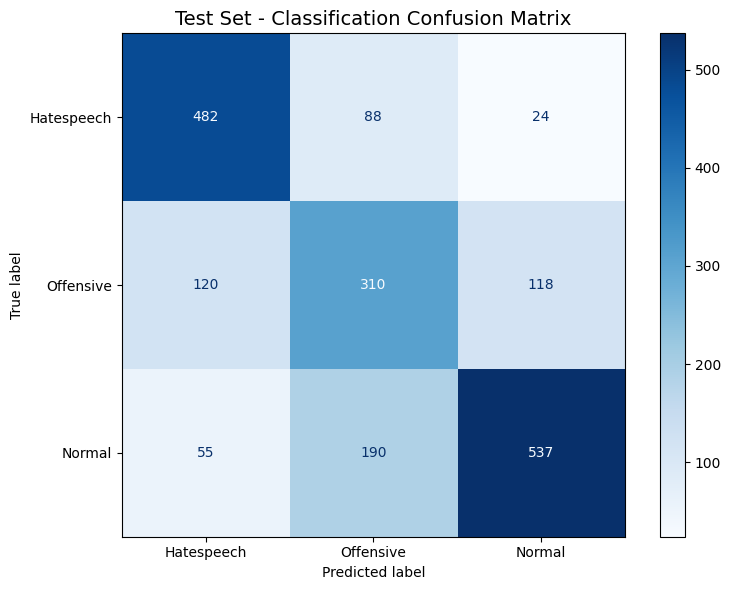

In [ ]:
# ============================================================
# Cell 10: Confusion Matrix Visualization
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_metrics['all_labels'], test_metrics['all_preds'])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=['Hatespeech', 'Offensive', 'Normal'])
disp.plot(ax=ax, cmap='Blues', values_format='d')

ax.set_title('Test Set - Classification Confusion Matrix', fontsize=14)

plt.tight_layout()
plt.savefig('models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Cell 11: Save test results and history
# ============================================================

results = {
    'test_cls_f1': test_metrics['cls_f1'],
    'test_span_f1': test_metrics['span_f1'],
    'test_target_f1': test_metrics['target_f1'],
    'test_severity_mae': test_metrics['severity_mae'],
    'history': history,
    'config': {
        'model': 'bert-base-uncased',
        'max_len': MAX_LEN,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'num_epochs': NUM_EPOCHS,
        'loss_weights': LOSS_WEIGHTS
    }
}

with open('models/multitask_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print('Results saved to models/multitask_results.pkl')
print('Model saved to models/catpic_multitask_bert_best.pt')
print('\n=== Notebook 2 Complete — Proceed to Notebook 3 ===')

Results saved to models/multitask_results.pkl
Model saved to models/catpic_multitask_bert_best.pt

=== Notebook 2 Complete — Proceed to Notebook 3 ===


In [ ]:
# ============================================================
# Cell 12: Backup BERT model + results to Google Drive
# ============================================================

if USE_DRIVE:
    print('Backing up BERT model to Google Drive...')

    # Model checkpoint
    shutil.copy('models/catpic_multitask_bert_best.pt',
                DRIVE_BASE + 'models/catpic_multitask_bert_best.pt')
    print('catpic_multitask_bert_best.pt -> Drive')

    # Results pickle
    shutil.copy('models/multitask_results.pkl',
                DRIVE_BASE + 'models/multitask_results.pkl')
    print('multitask_results.pkl -> Drive')

    # Training curves + confusion matrix
    for png in ['training_curves_multitask.png', 'confusion_matrix.png']:
        src = f'models/{png}'
        if os.path.exists(src):
            shutil.copy(src, DRIVE_BASE + f'models/{png}')
            print(f'{png} -> Drive')

    print(f'\nBERT model backed up to:\n {DRIVE_BASE}models/')

else:
    print('Drive not mounted — skipping Drive backup.')
    print('Run the Google Drive Setup cell (Cell 1b) first if you want Drive backup.')

Backing up BERT model to Google Drive...
catpic_multitask_bert_best.pt -> Drive
multitask_results.pkl -> Drive
training_curves_multitask.png -> Drive
confusion_matrix.png -> Drive

BERT model backed up to:
 /content/drive/MyDrive/CATPIC_Project/models/
